In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Raporda şov yapmak için grafik kütüphanesi
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

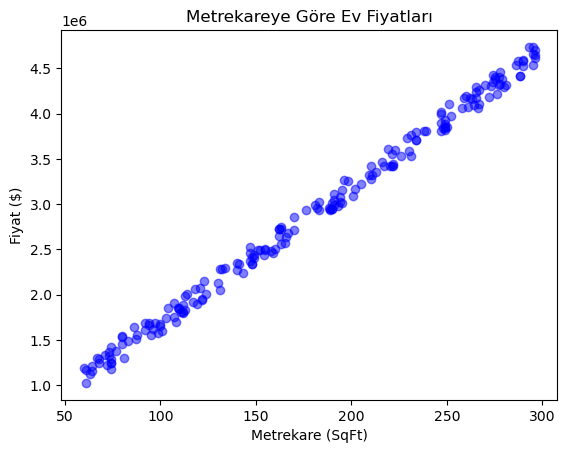

In [2]:
np.random.seed(42)
n_samples = 200

sqft = np.random.randint(60, 300, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
price = (sqft * 15000) + (bedrooms * 50000) + (bathrooms * 30000) + np.random.randint(-20000, 20000, n_samples)

df = pd.DataFrame({'SqFt': sqft, 'Bedrooms': bedrooms, 'Bathrooms': bathrooms, 'Price': price})
df.to_csv('house_prices.csv', index=False)

# Rapora koymalık ufak bir grafik: Metrekare arttıkça fiyat nasıl değişiyor?
plt.scatter(df['SqFt'], df['Price'], color='blue', alpha=0.5)
plt.title('Metrekareye Göre Ev Fiyatları')
plt.xlabel('Metrekare (SqFt)')
plt.ylabel('Fiyat ($)')
plt.show()

In [3]:
X = df[['SqFt', 'Bedrooms', 'Bathrooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model başarıyla eğitildi!")
print(f"Test Doğruluk Skoru (R2): {model.score(X_test, y_test):.2f}")

Model başarıyla eğitildi!
Test Doğruluk Skoru (R2): 1.00


In [4]:
joblib.dump(model, 'ev_fiyat_modeli.joblib')
print("Model 'ev_fiyat_modeli.joblib' adıyla AWS S3'e yüklenmeye hazır!")

Model 'ev_fiyat_modeli.joblib' adıyla AWS S3'e yüklenmeye hazır!
